<a href="https://colab.research.google.com/github/saskiaalifah/SaskiaAlifah_2411531002_ML2526/blob/main/Praktikum3/TugasLogisticRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IMPORT LIBRARY

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler

LOAD DATASET

In [4]:
url = "https://raw.githubusercontent.com/saskiaalifah/SaskiaAlifah_2411531002_ML2526/refs/heads/main/Praktikum3/Breast_cancer_data.csv"
df = pd.read_csv(url)
df.head()

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0
1,20.57,17.77,132.90,1326.0,0.08474,0
2,19.69,21.25,130.00,1203.0,0.10960,0
3,11.42,20.38,77.58,386.1,0.14250,0
4,20.29,14.34,135.10,1297.0,0.10030,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   mean_radius      569 non-null    float64
 1   mean_texture     569 non-null    float64
 2   mean_perimeter   569 non-null    float64
 3   mean_area        569 non-null    float64
 4   mean_smoothness  569 non-null    float64
 5   diagnosis        569 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 26.8 KB


In [6]:
df.describe()

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,diagnosis
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,1.000000


In [7]:
df.isnull().sum()

,0
mean_radius,0
mean_texture,0
mean_perimeter,0
mean_area,0
mean_smoothness,0
diagnosis,0


PREPROCESSING DATA

In [8]:
X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

In [17]:
y = df["diagnosis"]
y.value_counts()

,count
diagnosis,
1,357
0,212


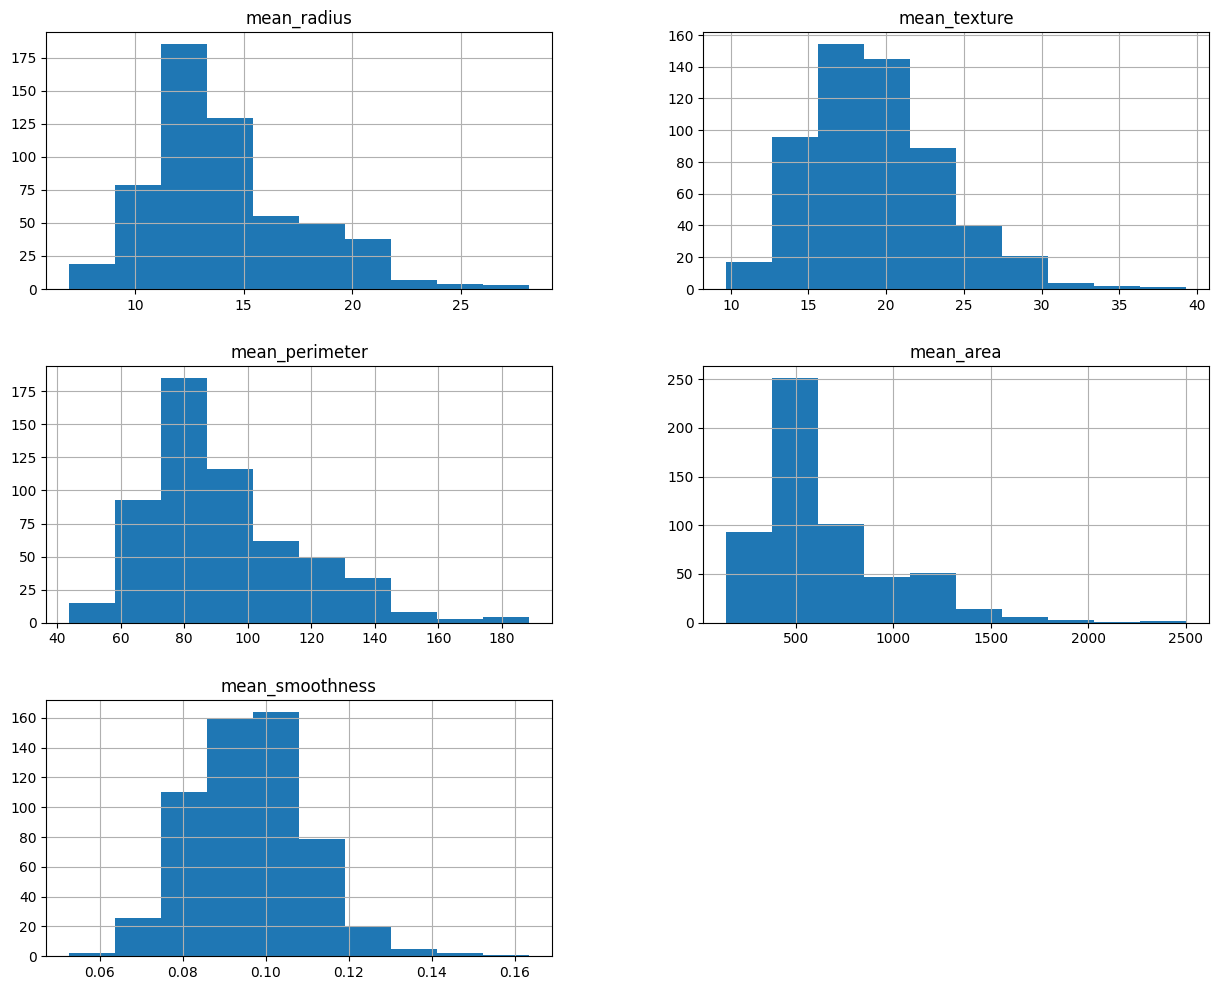

In [18]:
X.hist(figsize=(15,12))
plt.show()

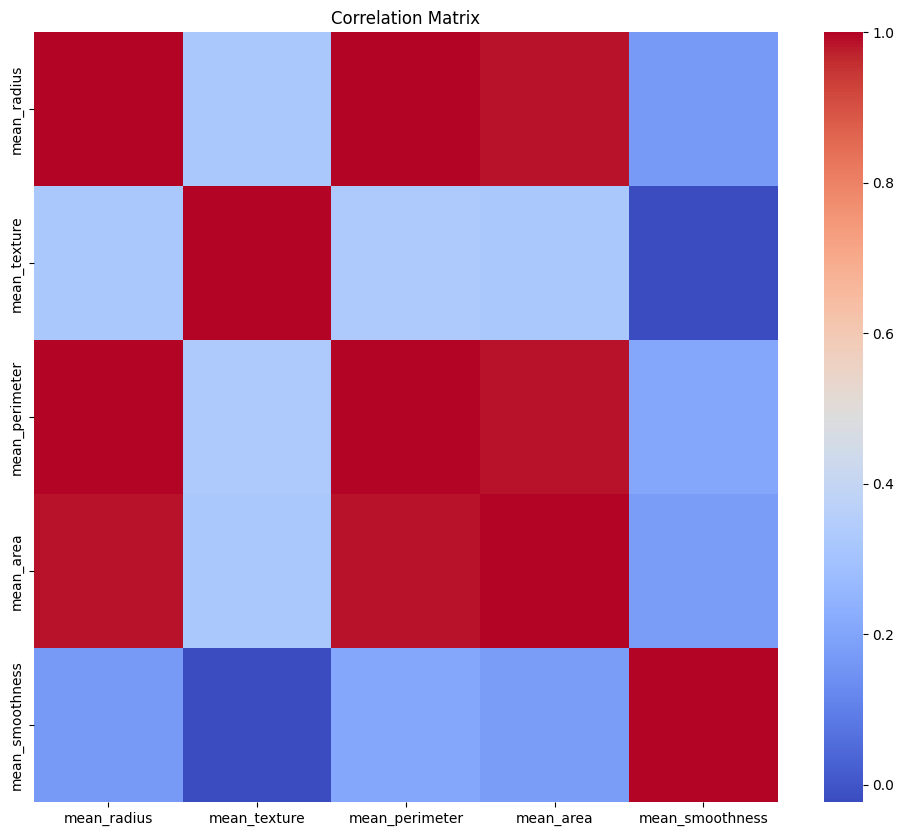

In [19]:
plt.figure(figsize=(12,10))
sns.heatmap(X.corr(), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

SPLIT DATA

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

##MODEL 1 :  LOGISTIC REGRESSION TANPA SCALING

In [22]:
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

In [23]:
y_pred = model.predict(X_test)

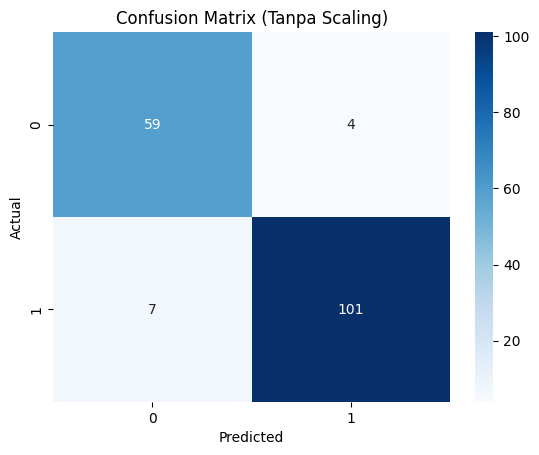

In [24]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix (Tanpa Scaling)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [25]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.935672514619883

Classification Report

              precision    recall  f1-score   support

           0       0.89      0.94      0.91        63
           1       0.96      0.94      0.95       108

    accuracy                           0.94       171
   macro avg       0.93      0.94      0.93       171
weighted avg       0.94      0.94      0.94       171



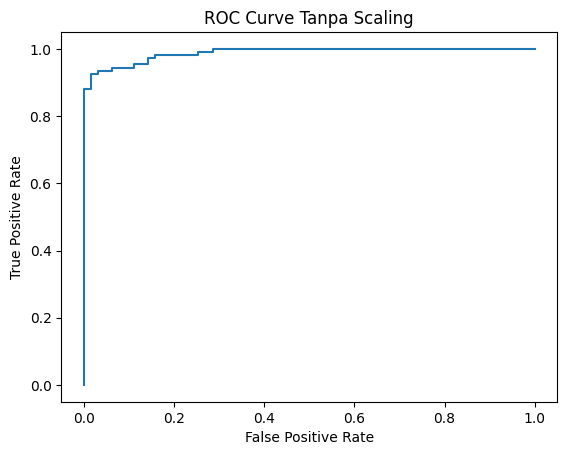

AUC Score: 0.9882422104644326


In [26]:
y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Tanpa Scaling")
plt.show()

print("AUC Score:", roc_auc_score(y_test, y_prob))

##MODEL 2 — LOGISTIC REGRESSION DENGAN SCALING

In [27]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
model_scaled = LogisticRegression(max_iter=5000)

model_scaled.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=5000)

In [29]:
y_pred_scaled = model_scaled.predict(X_test_scaled)

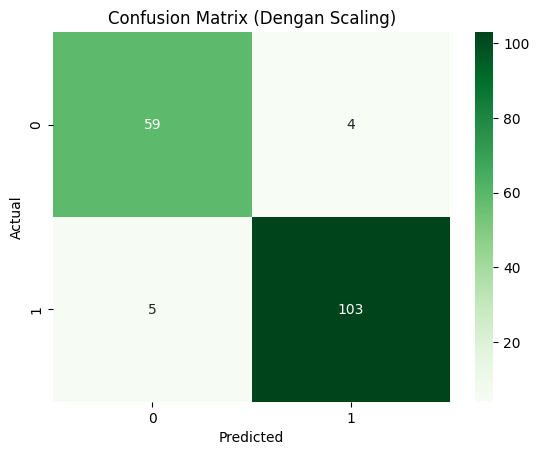

In [30]:
cm_scaled = confusion_matrix(y_test, y_pred_scaled)

sns.heatmap(cm_scaled, annot=True, fmt='d', cmap="Greens")
plt.title("Confusion Matrix (Dengan Scaling)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [31]:
print("Accuracy:", accuracy_score(y_test, y_pred_scaled))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_scaled))

Accuracy: 0.9473684210526315

Classification Report

              precision    recall  f1-score   support

           0       0.92      0.94      0.93        63
           1       0.96      0.95      0.96       108

    accuracy                           0.95       171
   macro avg       0.94      0.95      0.94       171
weighted avg       0.95      0.95      0.95       171



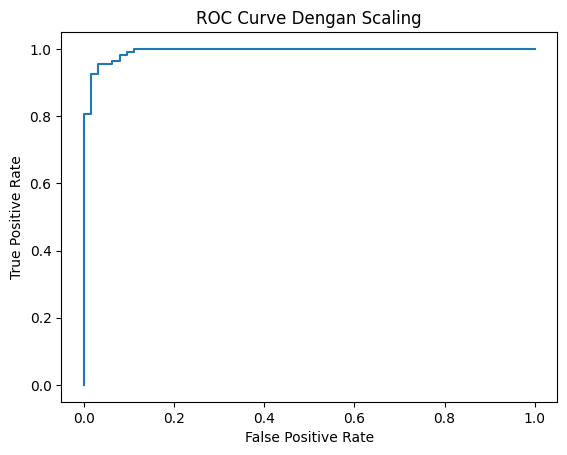

AUC Score: 0.9932392710170488


In [32]:
y_prob_scaled = model_scaled.predict_proba(X_test_scaled)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob_scaled)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Dengan Scaling")
plt.show()

print("AUC Score:", roc_auc_score(y_test, y_prob_scaled))

##PERCOBAAN BERBAGAI THRESHOLD

In [33]:
threshold = 0.3

y_pred_t03 = (y_prob_scaled >= threshold).astype(int)

print("Threshold 0.3")

print(confusion_matrix(y_test, y_pred_t03))

print(classification_report(y_test, y_pred_t03))

Threshold 0.3
[[ 52  11]
 [  0 108]]
              precision    recall  f1-score   support

           0       1.00      0.83      0.90        63
           1       0.91      1.00      0.95       108

    accuracy                           0.94       171
   macro avg       0.95      0.91      0.93       171
weighted avg       0.94      0.94      0.93       171



In [34]:
threshold = 0.5

y_pred_t05 = (y_prob_scaled >= threshold).astype(int)

print("Threshold 0.5")

print(confusion_matrix(y_test, y_pred_t05))

print(classification_report(y_test, y_pred_t05))

Threshold 0.5
[[ 59   4]
 [  5 103]]
              precision    recall  f1-score   support

           0       0.92      0.94      0.93        63
           1       0.96      0.95      0.96       108

    accuracy                           0.95       171
   macro avg       0.94      0.95      0.94       171
weighted avg       0.95      0.95      0.95       171



In [35]:
threshold = 0.7

y_pred_t07 = (y_prob_scaled >= threshold).astype(int)

print("Threshold 0.7")

print(confusion_matrix(y_test, y_pred_t07))

print(classification_report(y_test, y_pred_t07))

Threshold 0.7
[[62  1]
 [10 98]]
              precision    recall  f1-score   support

           0       0.86      0.98      0.92        63
           1       0.99      0.91      0.95       108

    accuracy                           0.94       171
   macro avg       0.93      0.95      0.93       171
weighted avg       0.94      0.94      0.94       171



##PERBANDINGAN MODEL

In [36]:
comparison = pd.DataFrame({
    "Model": ["Tanpa Scaling", "Dengan Scaling"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_scaled)
    ]
})

comparison

,Model,Accuracy
0,Tanpa Scaling,0.935673
1,Dengan Scaling,0.947368


In [37]:
print("Accuracy Threshold 0.3:", accuracy_score(y_test, y_pred_t03))
print("Accuracy Threshold 0.5:", accuracy_score(y_test, y_pred_t05))
print("Accuracy Threshold 0.7:", accuracy_score(y_test, y_pred_t07))

Accuracy Threshold 0.3: 0.935672514619883
Accuracy Threshold 0.5: 0.9473684210526315
Accuracy Threshold 0.7: 0.935672514619883
